# Task 1: Data Selection & Handling
It is our initial opinion that station choice is essentially arbitruary, provided we corectly pick 2 stations from each category. The data consists of 12 air quality monitoring stations in Beijing, 8 of which are classified as _Urban_ with the remainder classified as _Suburban_ (Xu et al., 2020). However to justify our choice, lets demonstrate the power of statistics, without jumping the gun of the full analysis in section 2.1. Lower levels of annual average PM2.5 concentrations were reported for the 4 suburban districts: Changpingzhen, Dingling, Huairouzhen, and Shunyixincheng (Batterman et al., 2016).

These lower annual averages concentrations should therefore be reflected in the first moment of the distributions:

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

We have an existing devlopment environment for Jupyter notebooks running on personal machines, but the solution has to work in CoLab, the logic below clones our repo and switches to the correct location when running from CoLab, however it does require secrets to be configured: 

In [55]:

if 'google.colab' in sys.modules:
    print("Running in Google Colab")

    from google.colab import userdata

    user = userdata.get('username')
    email = userdata.get('email')

    ! git config --global user.name {user}
    ! git config --global user.email {email}

    repo = userdata.get('repo')
    token = userdata.get('token')
    ! git clone https://{token}@github.com/{user}/{repo}.git

    %cd {repo}

else:
    print("Not running in Google Colab")

Not running in Google Colab


We need to adjust output settings to be able to see enough useful information:

In [63]:
pd.set_option('display.width', 120)

Only some of the dataset relates to pollution components, the remained are time and weather related:

In [74]:
pollution_components = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
meteorological_components = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

So far the literature provided in the assignment brief seems to lean toward the PM2.5 component, so lets try something with the averages:

In [ ]:
def get_sample_average(dataset: Path):
    df = pd.read_csv(dataset)
    return (df['PM2.5'].mean(), df['station'][0])

sample_averages = list()
[sample_averages.append(get_sample_average(dataset)) for dataset in Path('./AssessmentData').iterdir()]
sample_averages.sort()

for avg in sample_averages:
    print(f'Sample average(PM2.5): {avg[0]:.2f} for {avg[1]} station.')

Exactly as expected, even down to the ordering, B1-B4, outlined in Batterman et al. (2016).

Continuing with Batterman's classifications we decided on a station in each zone, Z1-Z4, for the maximum potential contrast in pollution concentrations:

| Station | Abbreviation | Batterman Zone | Reason Chosen |
| ------- | ------------- | -------------- | ------------- |
| Huairou | HR | Z1 | The only station in the ecological conservation zone |
| Shunyixincheng | SY | Z2 | a new urban development bordering Z1 |
| Nongzhanguan | NZG | Z3 | An urban functioning expanding bordering Z2 |
| Dongsi | DS | Z4 | A capital function core bordering Z3 |

As part of the task we need to combine those datasets into a single dataset, firstly, load the chosen datasets:

In [ ]:
station_data = list()
for dataset in Path('./AssessmentData').iterdir():
    if any(name in dataset.name for name in ['Huairou', 'Shunyi', 'Nongzhanguan', 'Dongsi']):
        station_data.append(pd.read_csv(dataset))

Then we need to merge them:

In [ ]:
time_cols = ['year', 'month', 'day', 'hour']

station_data = pd.concat(station_data, ignore_index=True)

Then, ensure proper handling of timestamps:

In [ ]:
station_data['datetime'] = pd.to_datetime(station_data[time_cols])
station_data = station_data.drop(time_cols, axis=1)
station_data = station_data.set_index('datetime')

Finally, ensure proper handling of station identifiers - It is a little early for one-hot encoding the stations, they are however _categorical_ data and while in our opinion the pandas approach _smells_, it looks to be the documented way to do it (McKinney, 2022, section 7.5):

In [ ]:
station_data['station'] = station_data['station'].astype('category')
station_data['station'].dtypes

# Task 2: Exploratory Data Analysis


## 2.1. Data Understanding
Provide an overview that may include the following, but not limited to:
▪ Number of rows and columns
▪ Column descriptions
▪ Data types
▪ Missing values
▪ Statistical Summary
▪ Initial observations & interpretation

What does the data actually look like, for that we check the shape:

In [ ]:
station_data.shape

Fourteen columns, which are defined as:

In [ ]:
station_data.columns

# TODO: Find the actual definitions - Know what they are but want correct units, etc

Of course, we originally had more four columns, but dropped those date/time columns in favour of the datetime index above.

The datatypes mostly make sense, but when it comes time to preprocess, wind direction and station will likely need one-hot encoding:

In [57]:
station_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 14 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   No       140256 non-null  int64   
 1   PM2.5    137012 non-null  float64 
 2   PM10     137938 non-null  float64 
 3   SO2      136871 non-null  float64 
 4   NO2      134959 non-null  float64 
 5   CO       132253 non-null  float64 
 6   O3       136446 non-null  float64 
 7   TEMP     140114 non-null  float64 
 8   PRES     140112 non-null  float64 
 9   DEWP     140109 non-null  float64 
 10  RAIN     140110 non-null  float64 
 11  wd       139315 non-null  object  
 12  WSPM     140135 non-null  float64 
 13  station  140256 non-null  category
dtypes: category(1), float64(11), int64(1), object(1)
memory usage: 19.1+ MB


TODO: Stick a box plot in here for the percentiles

The non-null count above hints that we have missing values which are totalled below and will need further investigation:

In [ ]:
station_data.isna().sum()

The describe() function gives us insight into the headline statistics:

In [56]:
station_data.describe()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,137012.000000,137938.000000,136871.000000,134959.000000,132253.000000,136446.000000,140114.000000,140112.000000,140109.000000,140110.000000,140135.000000
mean,17532.500,80.058037,102.409874,15.751506,47.123689,1214.821048,57.701269,13.294260,1011.439381,2.399703,0.064268,1.795314
std,10122.141,81.827316,92.019582,21.748133,33.647093,1136.971982,56.549142,11.549361,10.423915,13.850822,0.796465,1.265337
min,1.000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750,20.000000,33.000000,2.000000,21.000000,500.000000,12.000000,3.000000,1003.000000,-9.000000,0.000000,1.000000
50%,17532.500,55.000000,79.000000,7.000000,39.622900,900.000000,46.000000,14.300000,1011.000000,3.000000,0.000000,1.500000
75%,26298.250,111.000000,142.000000,20.000000,66.000000,1500.000000,81.000000,23.100000,1019.700000,15.100000,0.000000,2.300000
max,35064.000,941.000000,999.000000,315.000000,273.000000,10000.000000,1071.000000,41.100000,1042.800000,29.100000,46.400000,12.900000


Plotting the intervals reveals a mass of outliers, hidden in the actual plots due to the distorting effects. We should investigate further:

In [ ]:
for stat in pollution_components:
    station_data[[stat]].boxplot(showfliers=False)
    plt.show()

However our dataset is combined, during our pre-processing we will scale the values, but before we do that lets investigate the moments of the individual stations pollution distributions:

In [70]:
tmp = station_data.groupby('station')[pollution_components]
for station, data in tmp:
    print(f'{station}')
    for stat in pollution_components:
        print(f'{stat}\tmean: {data[stat].mean():.2f}\tmedian: {data[stat].median():.2f}\tmode: {data[stat].mode().iloc[0]:.2f}\tvariance: {data[stat].std()**2:.2f}\tskew: {data[stat].skew():.2f}\tkurtosis: {data[stat].kurt():.2f}')

Dongsi
PM2.5	mean: 86.19	median: 61.00	mode: 3.00	variance: 7495.25	skew: 1.98	kurtosis: 5.65
PM10	mean: 110.34	median: 86.00	mode: 6.00	variance: 9647.14	skew: 1.94	kurtosis: 6.15
SO2	mean: 18.53	median: 10.00	mode: 2.00	variance: 524.67	skew: 2.58	kurtosis: 9.46
NO2	mean: 53.70	median: 47.00	mode: 20.00	variance: 1153.23	skew: 1.03	kurtosis: 1.23
CO	mean: 1330.07	median: 1000.00	mode: 300.00	variance: 1419209.72	skew: 2.45	kurtosis: 8.65
O3	mean: 57.21	median: 44.13	mode: 2.00	variance: 3367.86	skew: 3.51	kurtosis: 43.26
Huairou
PM2.5	mean: 69.63	median: 47.00	mode: 3.00	variance: 5072.99	skew: 1.92	kurtosis: 5.19
PM10	mean: 91.48	median: 69.00	mode: 6.00	variance: 6937.15	skew: 1.91	kurtosis: 6.94
SO2	mean: 12.12	median: 4.00	mode: 2.00	variance: 357.09	skew: 3.72	kurtosis: 21.89
NO2	mean: 32.50	median: 25.00	mode: 2.00	variance: 701.70	skew: 1.39	kurtosis: 2.39
CO	mean: 1022.55	median: 800.00	mode: 300.00	variance: 807730.43	skew: 2.88	kurtosis: 14.63
O3	mean: 59.82	median: 49.00	m

/tmp/ipykernel_126526/2476210133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = station_data.groupby('station')[pollution_components]


Every one of our pollution measures shows a mean greater than the median. The distributions all have positive skew and kurtosis, some of which are extreme. This confirms our comment about the outliers above.

From these numbers we can deduce the distributions are *not* Gaussian, are left skewed with some distrubutions having significant outliers. Some sample graphs demonstrate this:

In [76]:
def plot_distributions(station: str, data: pd.Series, components=pollution_components):

    fig, ax = plt.subplots(len(components), 1, figsize=(10, 15))

    for i, stat in enumerate(components):
        ax[i].hist(station_data[stat], bins=50)#-station_data[stat].mean())/station_data[stat].std(), bins=50)
        #ax[i].plot(station_data[stat].mean(), 'bx')
        ax[i].set(title=f'{station} - {stat}', ylabel='Concentration')

    plt.show()

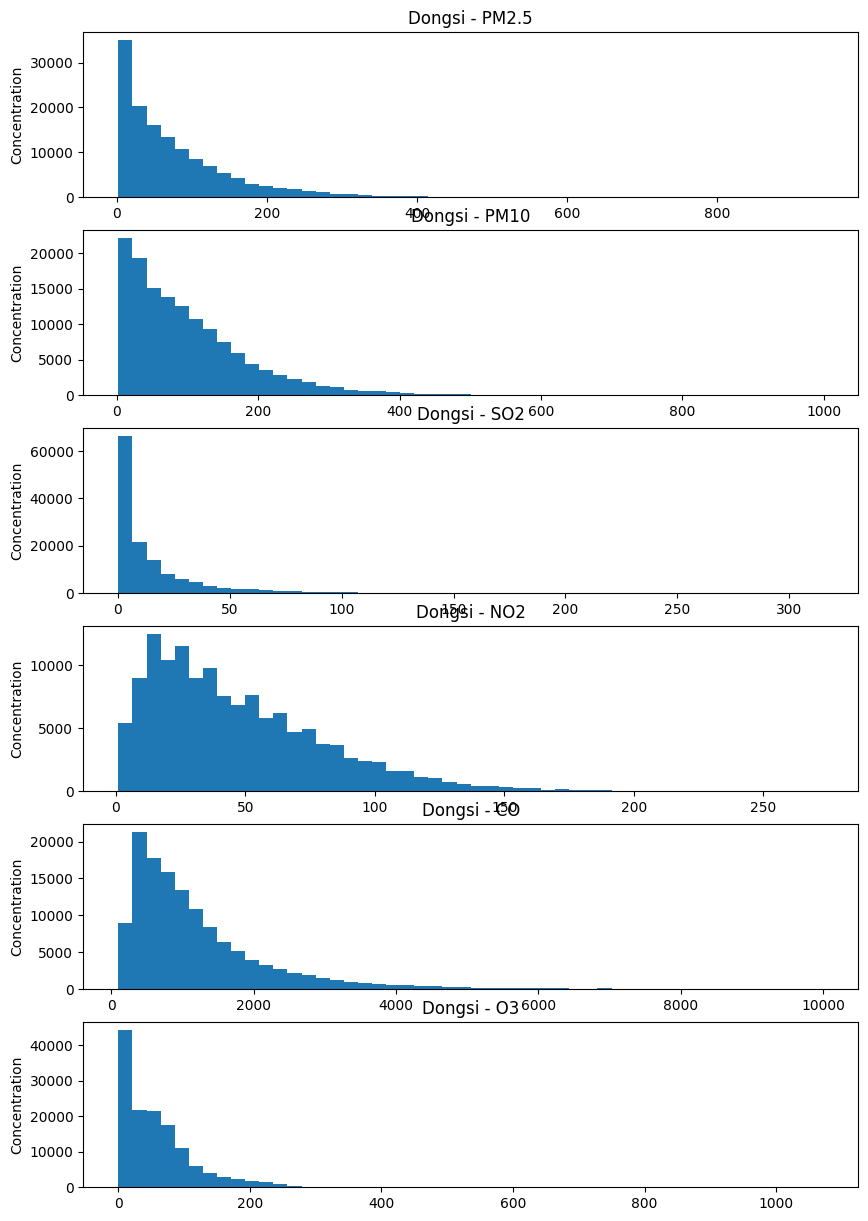

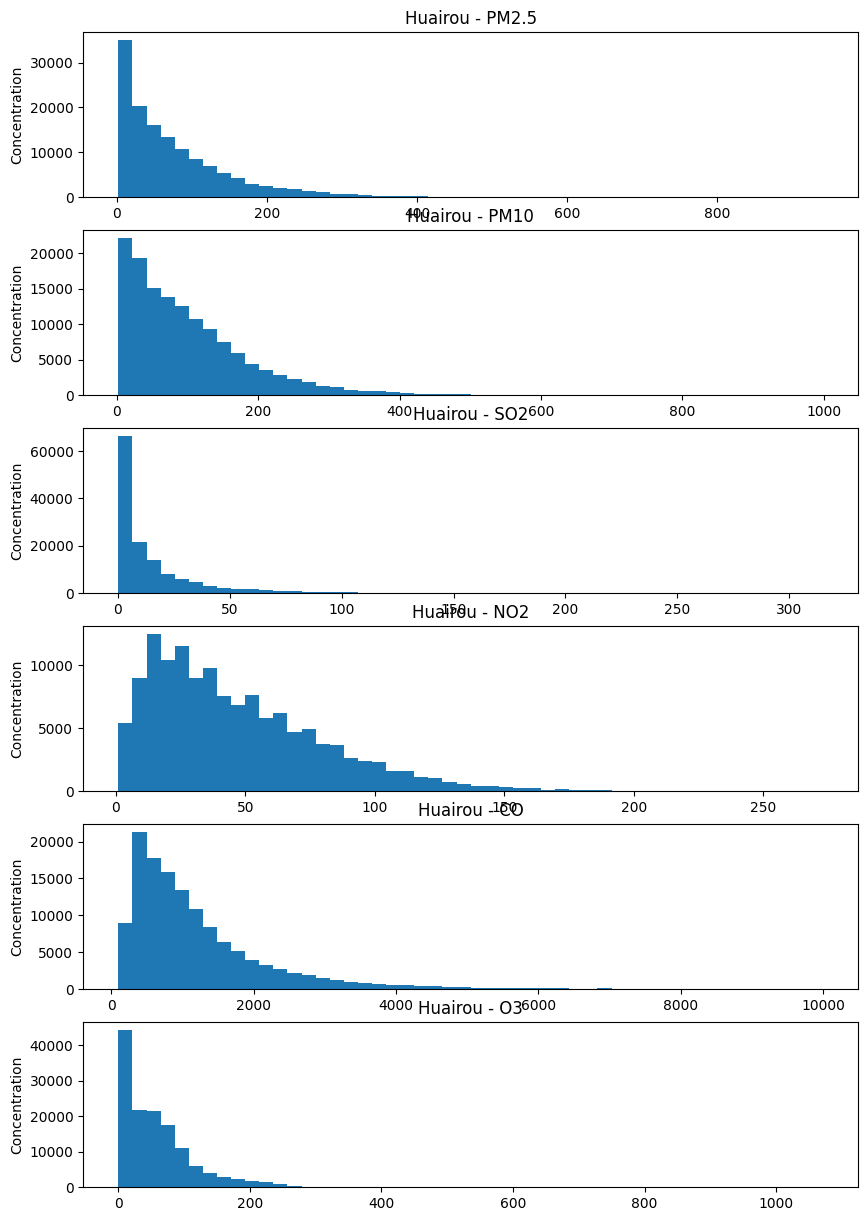

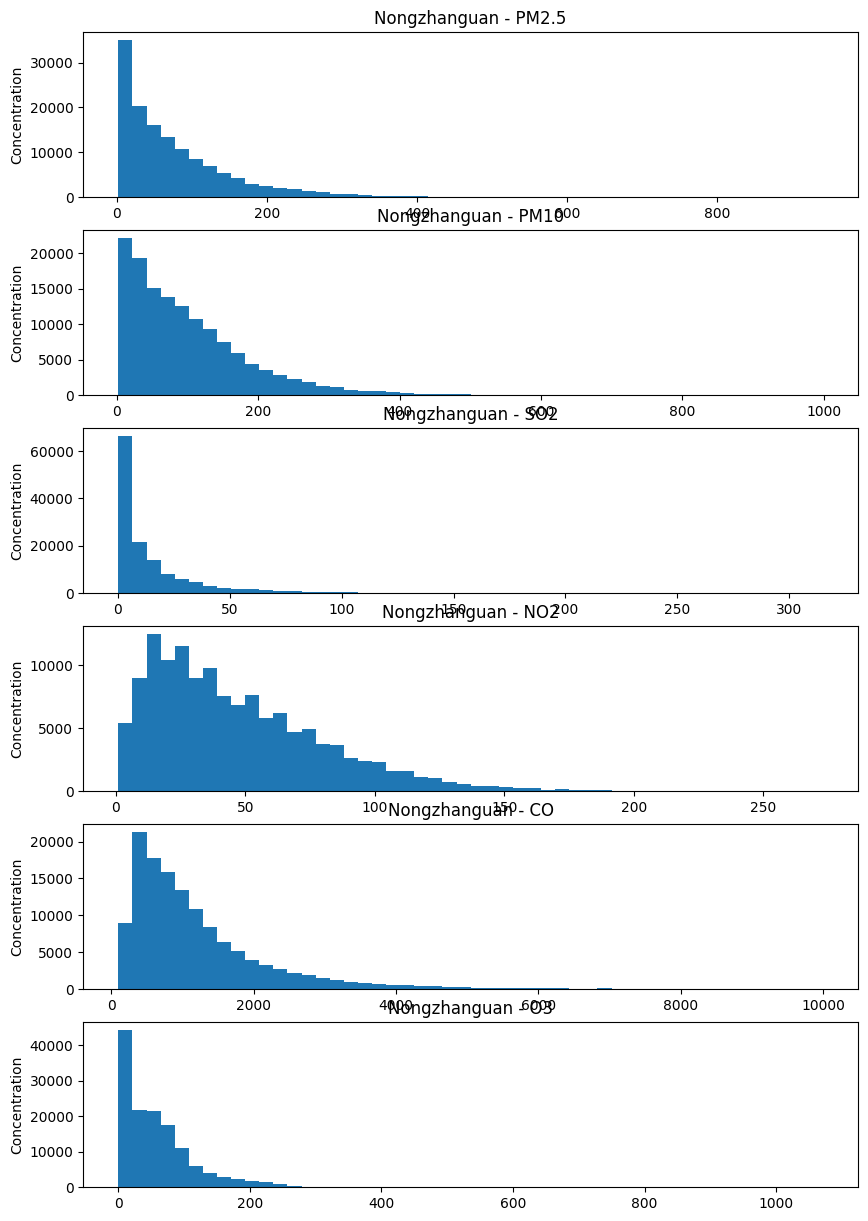

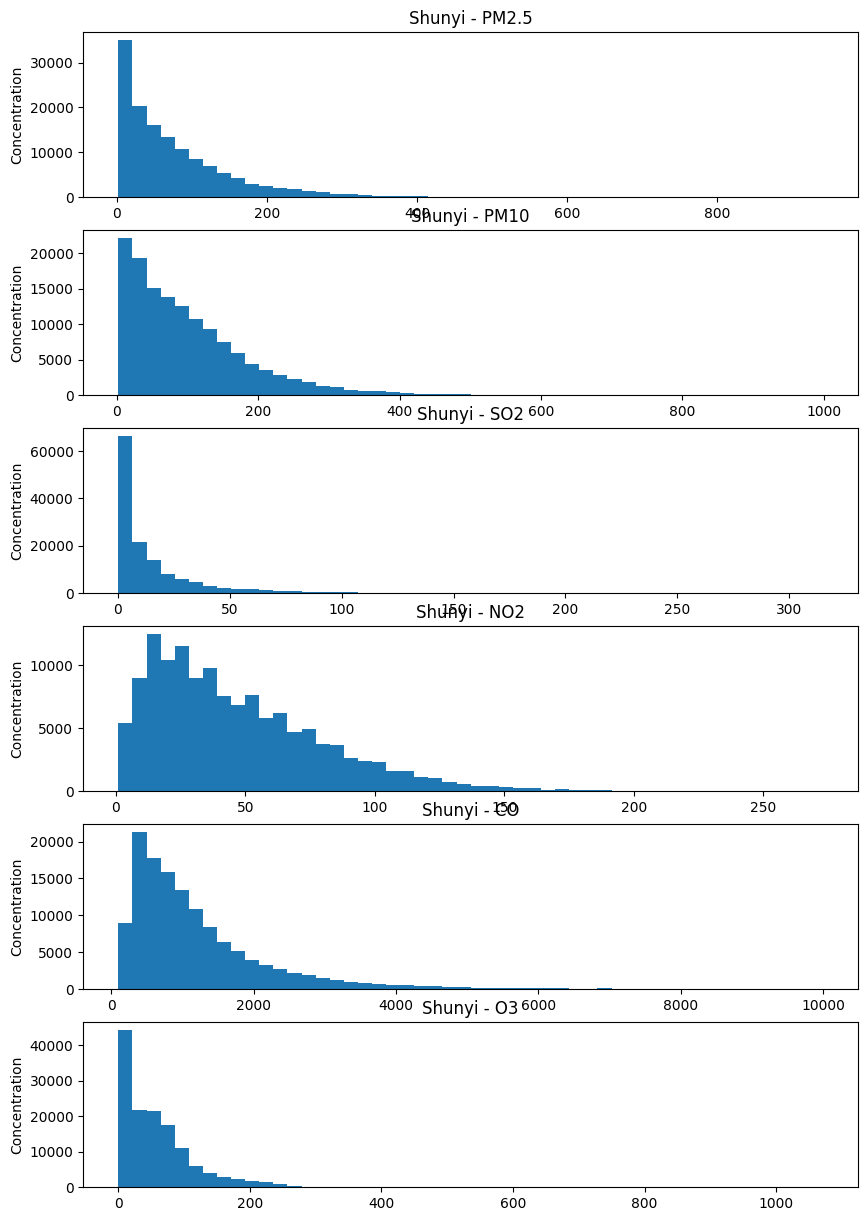

In [78]:
for station, data in tmp:
    plot_distributions(station, data)

However compare that with the distributions of the meteorological data, what a wonderful contrast, look at those bimodal distributions for Pressure and Dew Point, while Rainfall is almost Bernoulli, i.e. on or off:

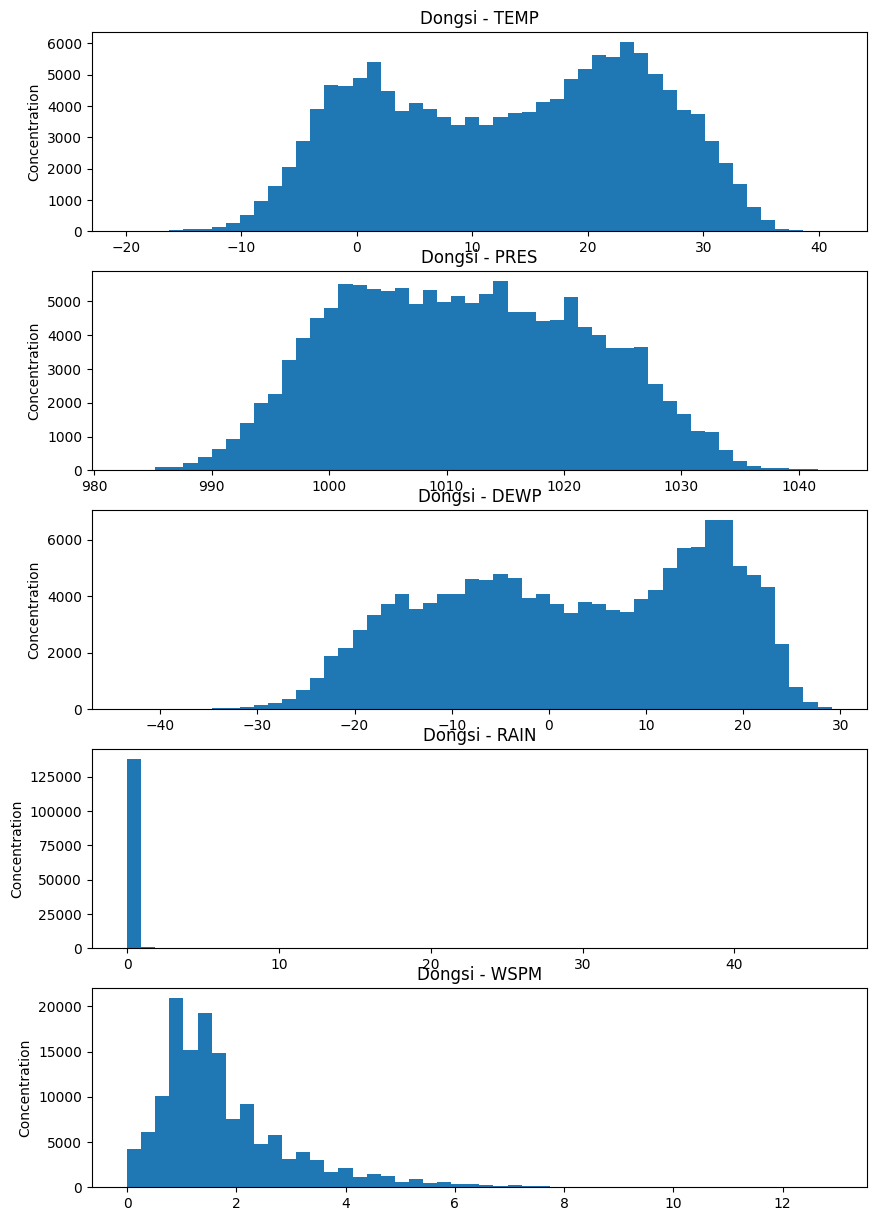

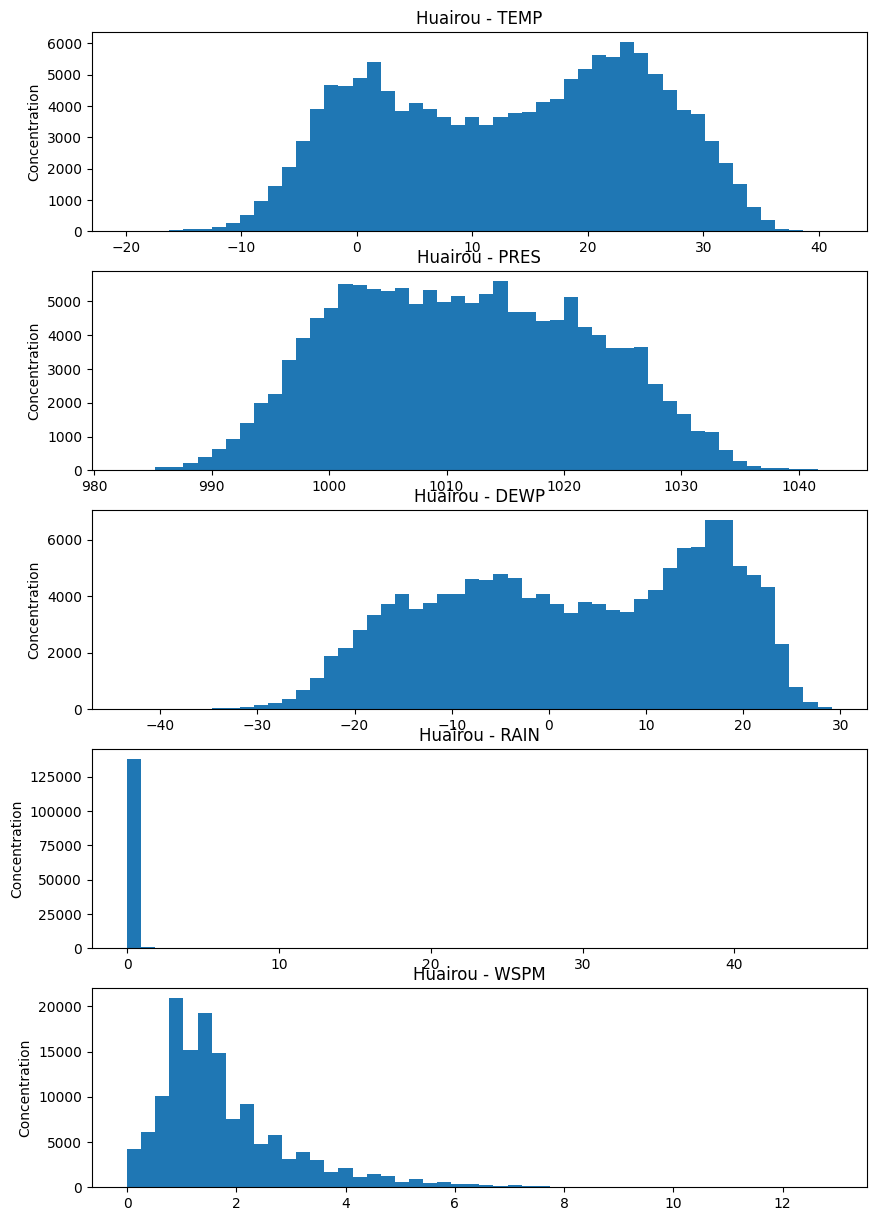

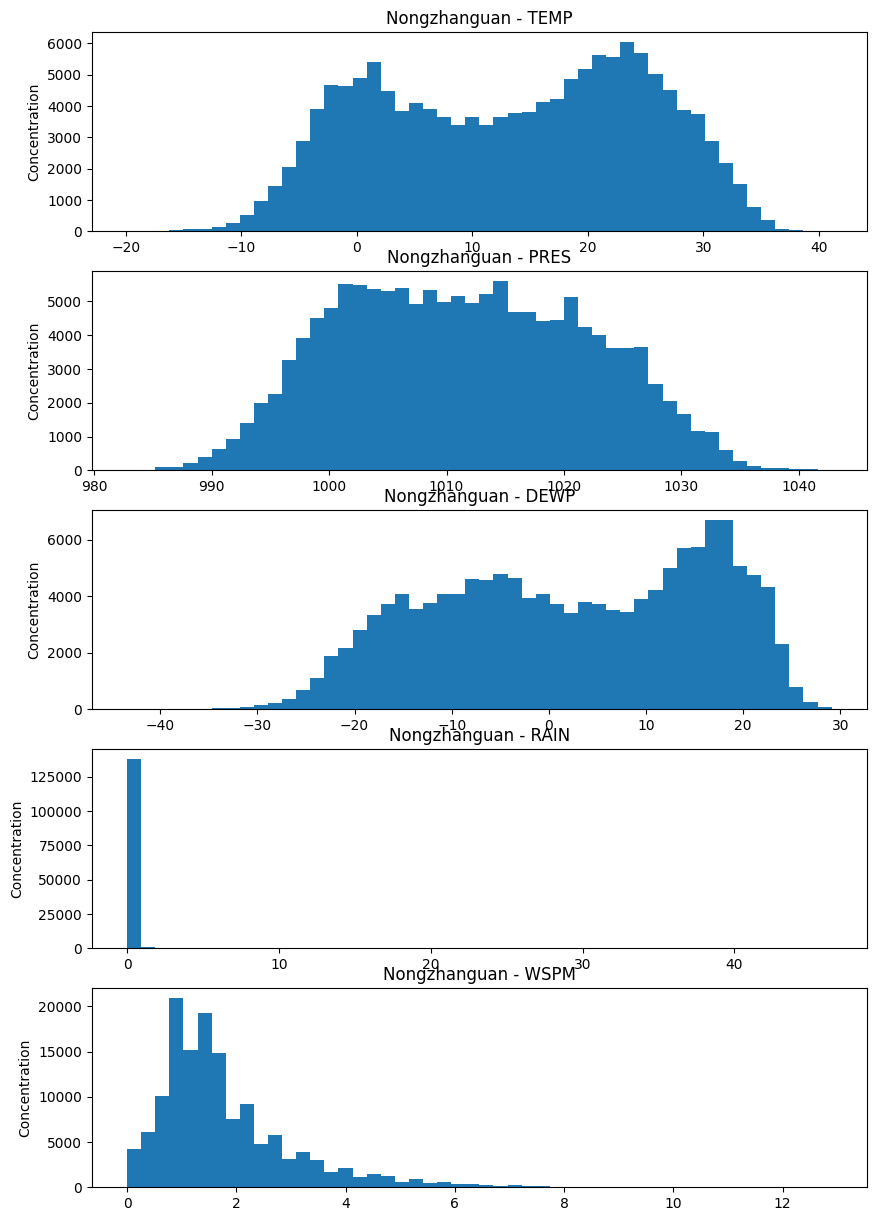

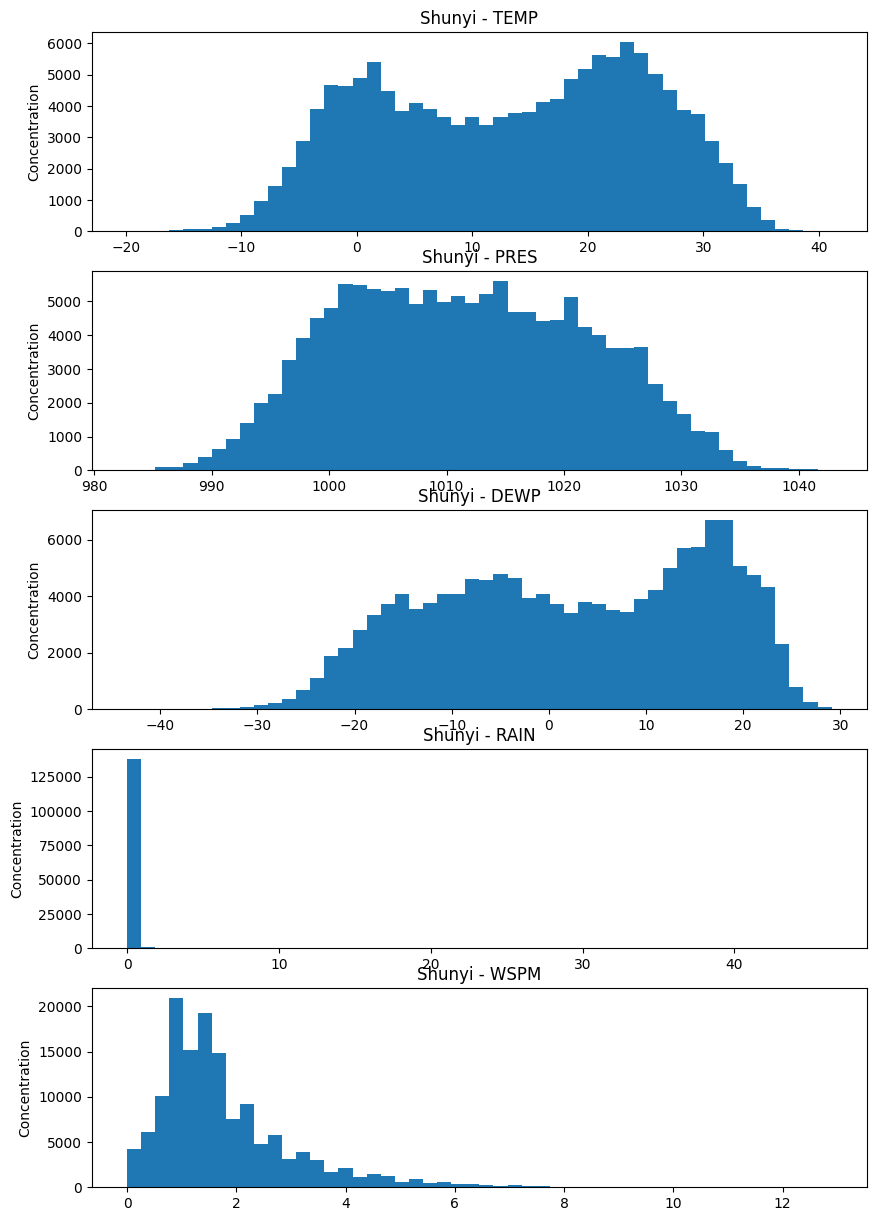

In [79]:
for station, data in tmp:
    plot_distributions(station, data, meteorological_components)

We understand that, perhaps, this is unnecesary for the purposes of the assignment but as the sub-reddit says, _r/dataisbeautiful_ and we wanted to explore it before we started pre-processing.

## 2.2. Data Preprocessing
Perform the necessary data preprocessing steps, including but not limited to handling missing values,
removing duplicate entries, feature engineering (e.g., datetime components, AQI levels), and overall data
cleaning on the main dataset.

In [ ]:
for station, data in tmp:
    print(data.isna().sum())

In [ ]:
import seaborn as sns

for station, data in tmp:
    plt.figure(figsize=(12, 3))
    sns.heatmap(
        data.isna().T,
    )
    plt.title(f"Heatmap for {station}")
    plt.show()

Some of those gaps look considerable CO for example, but the actual numbers of NAs doesn't visually tally with the heatmaps, which means even the small gaps could be considerable. Lets investigate that.

In [ ]:
pd.set_option('display.max_rows', None)

station_data[station_data['station']=='Dongsi'].loc['2016-09-06':'2016-09-07', 'PM2.5']

That view demonstrates our fears, there are extended periods of NAs not just individual readings which means we have to be smarter than just using a method like linear interpolation.

For now just replace them with the mean values, but this needs to be revisited.

In [ ]:
station_data[pollution_components] = station_data[pollution_components].fillna(station_data[pollution_components].mean())

Since filling out NA values, a straightforward check for duplicates indicates we do not have any:

In [ ]:
print(station_data.duplicated().sum())

We need to consider outliers:

In [ ]:
raise NotImplementedError

The literature review points out that Government edicts are in place which affect what days of the week people can drive cars, this suggests seasonality. Lets include day of the week:

In [ ]:
station_data['weekday'] = station_data.index.dayofweek
station_data.head()

Holidays affect people's behaviour too, so lets capture that:

In [ ]:
import holidays

hols = holidays.country_holidays('CN')
station_data['holiday'] = station_data.index.to_series().apply(lambda hol: hol in hols)
station_data[station_data['holiday']==True].count()

Furthermore, the literature also concludes that pollution is worse during the winter/heating season, further seasonality may be captured by including week numbers - %W indicating Monday should be considered the first day of the week:

In [ ]:
station_data['week_no'] = station_data.index.strftime('%W')
station_data

Now is a good point to add one-hot encoding:

In [ ]:
pd.set_option('display.max_columns', None)

station_data = pd.get_dummies(station_data)
station_data.head()

In [ ]:
pd.set_option('display.max_rows', 5)

## 2.3. Statistical/Computational Analysis & Visualisation
Perform the necessary steps such as univariate (distribution of pollutants & meteorological variables),
bivariate(e.g. relationships such as PM2.5 vs. Temp, NO2 vs. O3 but not limited to these), and
multivariate analysis (correlation, heatmaps, pairplots), statistical summary, and visualizing the data
(Various charts and graphs, such as bar charts, line charts and scatter plots) that will help in
understanding relationships between variables and to gain important insights from data. Interpret the
key results to demonstrate understanding generated from statistical and visual analysis.
• Explore the dataset however you find meaningful. You may examine different variables, compare
stations, investigate temporal behaviours, or analyse interactions between pollutants and
meteorological factors. Choose the approaches that you believe best help you understand and interpret
the dataset, and present the insights you consider most relevant

In [ ]:
#from scipy.stats import ks_2samp

d = station_data[station_data['station']=='Dongsi']
h = station_data[station_data['station']=='Huairou']
n = station_data[station_data['station']=='Nongzhanguan']
s = station_data[station_data['station']=='Shunyi']
#ks_2samp(d['PM2.5'].dropna(), h['PM2.5'].dropna())
#ks_2samp(d['PM2.5'].dropna(), n['PM2.5'].dropna())
#ks_2samp(h['PM2.5'].dropna(), s['PM2.5'].dropna())
#ks_2samp(d['PM2.5'].dropna(), d['PM10'].dropna())

In [ ]:
# station_cats = pd.get_dummies(station_data['station'])
# station_data = pd.concat([station_data, station_cats], axis=1)
# station_data = station_data.drop('station', axis=1)

# Task 3: Model Building
After completing all the tasks listed under Task 1 and Task 2, identify and implement the best practices
to build a suitable machine-learning model (e.g., feature scaling, encoding techniques, variable selection,
and parameter optimization).
• Justify your modelling decisions and evaluate model performance using appropriate metrics.

# Task 4: Application Development
Develop an interactive application with a graphical user interface (GUI). The application should include multiple
sections/pages that allow users to explore
• The dataset section,
• Visualization section, and
• Model outputs section.
You may design the structure in any way you find appropriate, but it should enable clear navigation between the
key components of your workflow.

In [ ]:
import streamlit as st

st.title("Hey bub")
# for station, data in tmp:
#     st.plot(plot_distributions(station, data))

# Task 5: Version Control
Use GitHub for version control.
• Commit changes regularly with clear, descriptive messages, for example, added PM2.5 prediction
model”, “Created correlation heatmap,” etc.
• Maintain an organised repository structure and include screenshots of:
▫ GitHub commit history
▫ GitHub project repository layout

# References
McKinney, W. (2022) _Python for Data Analysis, 3rd Edition_. O'Reilly Media, Inc. Available at: https://learning.oreilly.com/library/view/python-for-data/9781098104023/
